In [1]:
# Setup
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import display

# Locate project root
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "src").exists():
            PROJECT_ROOT = parent
            break

SRC = PROJECT_ROOT / "src"
DATA = PROJECT_ROOT / "data"
RESULTS = PROJECT_ROOT / "results"
FIGURES = RESULTS / "figures"
TABLES = RESULTS / "tables"
FASTA = RESULTS / "fasta"

for folder in [RESULTS, FIGURES, TABLES, FASTA]:
    folder.mkdir(parents=True, exist_ok=True)

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /Users/tomasmanea/Desktop/Everything 2.0/Fall2024/QBIO481/A4


In [2]:
# Import Custom Modules
from data_loader import (
    load_sequence_affinity,
    normalize_affinity,
    load_all_shape_data,
    write_fasta,
)

from features import prepare_features
from model import perform_ridge_cv
from plots import (
    plot_r2_comparison,
    plot_shape_comparison,
    plot_2mer_vs_shape_comparison,
)

In [3]:
# Define TFs and File Paths
tf_names = ["Max", "Mad", "Myc"]

sequence_files = {
    "Max": DATA / "Max.txt",
    "Mad": DATA / "Mad.txt",
    "Myc": DATA / "Myc.txt",
}

shape_files = {
    "Max": {
        "MGW": DATA / "Max_MGW.txt",
        "ProT": DATA / "Max_ProT.txt",
        "Roll": DATA / "Max_Roll.txt",
        "HelT": DATA / "Max_HelT.txt",
    },
    "Mad": {
        "MGW": DATA / "Mad_MGW.txt",
        "ProT": DATA / "Mad_ProT.txt",
        "Roll": DATA / "Mad_Roll.txt",
        "HelT": DATA / "Mad_HelT.txt",
    },
    "Myc": {
        "MGW": DATA / "Myc_MGW.txt",
        "ProT": DATA / "Myc_ProT.txt",
        "Roll": DATA / "Myc_Roll.txt",
        "HelT": DATA / "Myc_HelT.txt",
    },
}

In [4]:
# Load, then Normalize Affinity Data
sequence_data = {}

for tf in tf_names:
    df = load_sequence_affinity(sequence_files[tf])
    df = normalize_affinity(df)
    sequence_data[tf] = df

    print(f"{tf}: {df.shape}")
    display(df.head())

Max: (8568, 2)


,Sequence,Affinity
0,GAAGCCCTGGCGGGGCGCGTGCCCGCCGCCGCCGCC,0.106881
1,TCCCGGGGCTAGAGGCATGTGGACTCAGGAGGATGA,0.232205
2,GGCGCTGCCGGACTGCGCGTGGAGTGGCGCGCTGCT,0.154269
3,GCAGCTCGCCCGGGCCACGCGGTGCCGGCCCTCGGC,0.378770
4,GGAATTACCTTCATCCACATGGTTGAAGCTGGCTGG,0.415513


Mad: (7534, 2)


,Sequence,Affinity
0,GGGCATGAAAGCCACCTCGTGGTTTTGCAGCAAGTG,0.413406
1,CGGGGAGGAGCCACCCACGCGCCACAGCAAGTCCTG,0.185719
2,GGCGGCCCGGGCATCCACGTGGGTCGGGCTCCTGGT,0.796084
3,TGCGGCTTCGGCTTCCACGCGGCATCCTAGGTAAGC,0.283824
4,TGCTCGCCTGCCTGCCATGTGCAGCGGCCCCTTTGT,0.297382


Myc: (6926, 2)


,Sequence,Affinity
0,ACCGACCGGCGCGGGCACGAGGCAATGGCGGCCGGG,0.174288
1,AACAGCGCCACCGGCCTCGTGCACTTCTTCCACTGT,0.217422
2,GCGGCCGGTCTGCACCATGCTGCGAACGTCCGTCCT,0.133137
3,TTATTGAGCCCCTACCATGTGCCAGGCCCTGGGCTA,0.311328
4,CCCCTCAGCTGCTTCCTCGTGGCGCTGATCATCTGG,0.319377


In [5]:
# Load Shape Data
shape_data = load_all_shape_data(shape_files)

for tf in tf_names:
    print(f"\n{tf}")
    for feat, arr in shape_data[tf].items():
        print(f"  {feat}: {arr.shape}")


Max
  MGW: (8568, 36)
  ProT: (8568, 36)
  Roll: (8568, 35)
  HelT: (8568, 35)

Mad
  MGW: (7534, 36)
  ProT: (7534, 36)
  Roll: (7534, 35)
  HelT: (7534, 35)

Myc
  MGW: (6926, 36)
  ProT: (6926, 36)
  Roll: (6926, 35)
  HelT: (6926, 35)


In [6]:
# Creating FASTA Files
for tf in tf_names:
    fasta_path = FASTA / f"{tf}.fasta"
    write_fasta(sequence_data[tf], fasta_path)
    print("Wrote:", fasta_path)

Wrote: /Users/tomasmanea/Desktop/Everything 2.0/Fall2024/QBIO481/A4/results/fasta/Max.fasta
Wrote: /Users/tomasmanea/Desktop/Everything 2.0/Fall2024/QBIO481/A4/results/fasta/Mad.fasta
Wrote: /Users/tomasmanea/Desktop/Everything 2.0/Fall2024/QBIO481/A4/results/fasta/Myc.fasta


In [7]:
# Model Run
encoding_types = ["1-mer", "2-mer", "1-mer+shape"]
shape_features = [None, "MGW", "ProT", "Roll", "HelT"]

r2_results = {}
rows = []

for tf in tf_names:
    print(f"\nRunning {tf}...")

    # 1-mer and 2-mer
    for enc in ["1-mer", "2-mer"]:
        X, y = prepare_features(sequence_data, shape_data, tf, enc)
        r2 = perform_ridge_cv(X, y)

        r2_results[(tf, enc)] = r2

        rows.append({
            "TF": tf,
            "Encoding": enc,
            "Shape": "",
            "R2": r2,
        })

    # 1-mer + shape
    for shape in shape_features:
        X, y = prepare_features(
            sequence_data,
            shape_data,
            tf,
            "1-mer+shape",
            shape,
        )

        r2 = perform_ridge_cv(X, y)
        key = (tf, "1-mer+shape", shape or "all")

        r2_results[key] = r2

        rows.append({
            "TF": tf,
            "Encoding": "1-mer+shape",
            "Shape": shape or "all",
            "R2": r2,
        })

results_df = pd.DataFrame(rows)
display(results_df)


Running Max...

Running Mad...

Running Myc...


,TF,Encoding,Shape,R2
0,Max,1-mer,,0.785117
1,Max,2-mer,,0.865478
2,Max,1-mer+shape,all,0.927722
3,Max,1-mer+shape,MGW,0.839330
4,Max,1-mer+shape,ProT,0.839669
5,Max,1-mer+shape,Roll,0.896689
6,Max,1-mer+shape,HelT,0.875303
7,Mad,1-mer,,0.773627
8,Mad,2-mer,,0.855507
9,Mad,1-mer+shape,all,0.949241


In [8]:
# Table Saving
out_csv = TABLES / "r2_results.csv"
results_df.to_csv(out_csv, index=False)

print("Saved:", out_csv)

Saved: /Users/tomasmanea/Desktop/Everything 2.0/Fall2024/QBIO481/A4/results/tables/r2_results.csv


(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': '2-mer vs Shape-Based R² Comparison'}, xlabel='2-mer R²', ylabel='Shape-based R²'>)

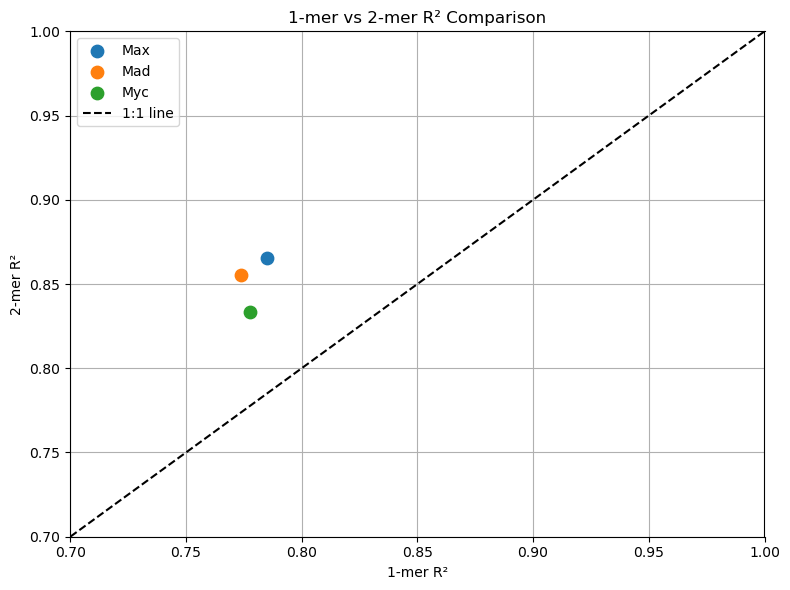

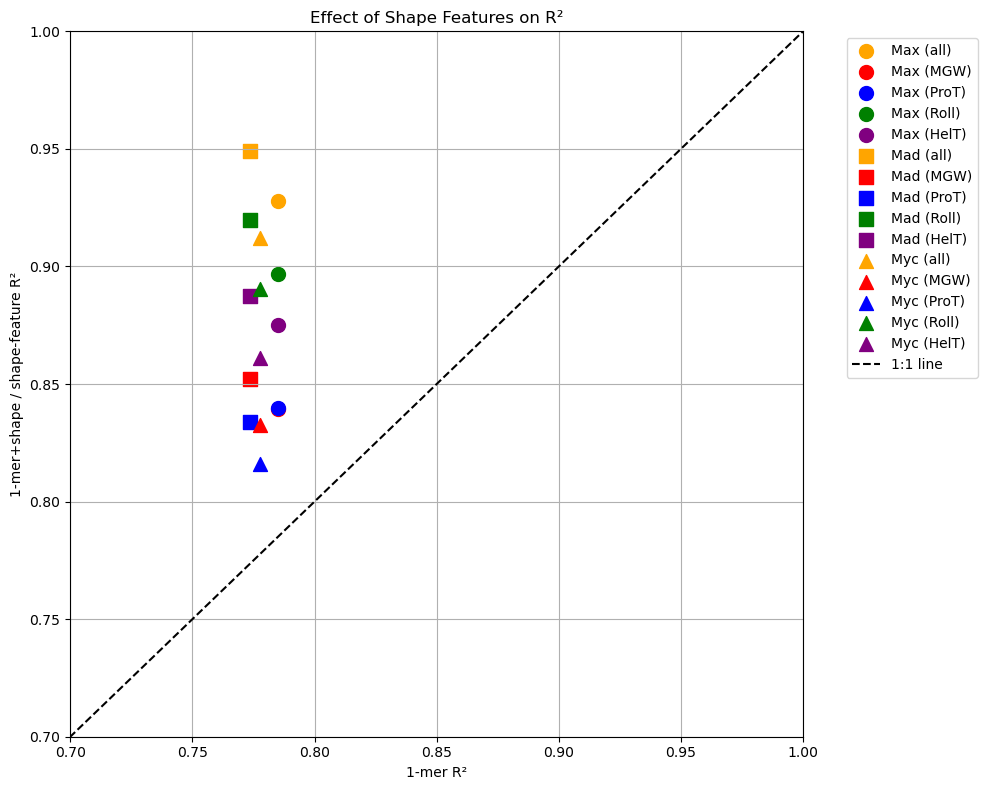

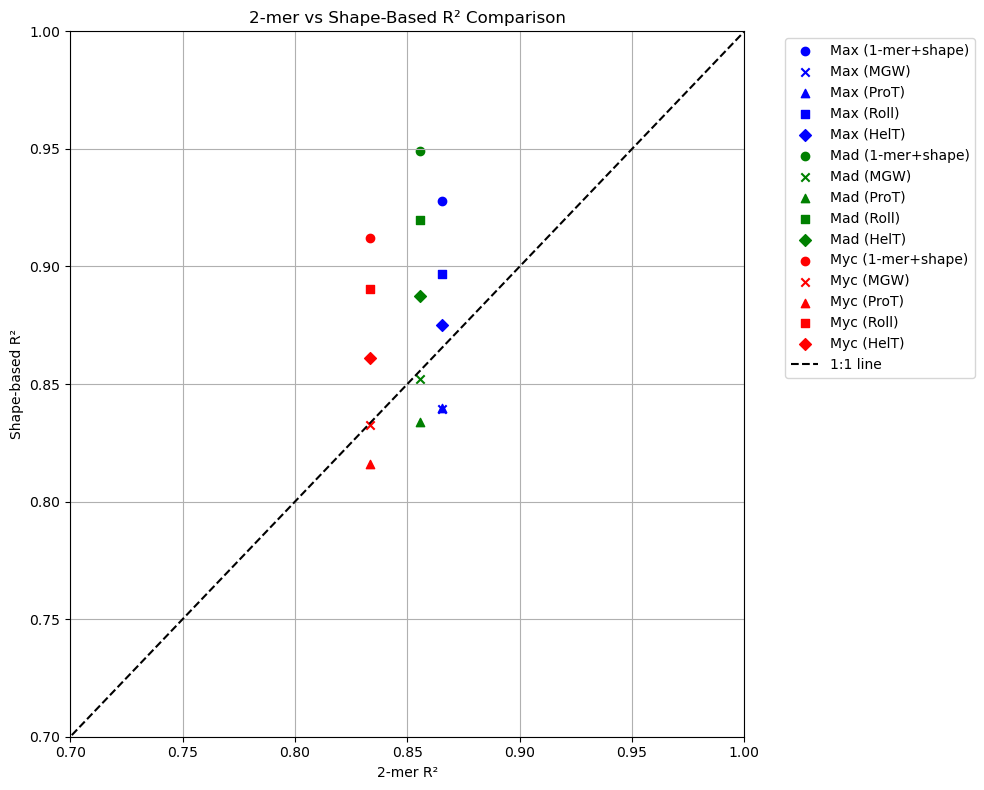

In [9]:
# Creating Plots
plot_r2_comparison(
    r2_results,
    tf_names,
    save_path=FIGURES / "r2_1mer_vs_2mer.png",
)

plot_shape_comparison(
    r2_results,
    tf_names,
    save_path=FIGURES / "r2_shape_effect.png",
)

# build nested dict for last plot
nested = {}
for tf in tf_names:
    nested[tf] = {
        "2-mer": r2_results[(tf, "2-mer")],
        "1-mer+shape": r2_results.get((tf, "1-mer+shape", "all")),
        "MGW": r2_results.get((tf, "1-mer+shape", "MGW")),
        "ProT": r2_results.get((tf, "1-mer+shape", "ProT")),
        "Roll": r2_results.get((tf, "1-mer+shape", "Roll")),
        "HelT": r2_results.get((tf, "1-mer+shape", "HelT")),
    }

plot_2mer_vs_shape_comparison(
    nested,
    tf_names,
    save_path=FIGURES / "r2_2mer_vs_shape.png",
)

In [10]:
# Total Synthesis
print("Pipeline complete.")

print("\nOutputs:")
print("Tables:", TABLES)
print("Figures:", FIGURES)
print("FASTA:", FASTA)

display(results_df.sort_values(["TF", "Encoding", "Shape"]))

Pipeline complete.

Outputs:
Tables: /Users/tomasmanea/Desktop/Everything 2.0/Fall2024/QBIO481/A4/results/tables
Figures: /Users/tomasmanea/Desktop/Everything 2.0/Fall2024/QBIO481/A4/results/figures
FASTA: /Users/tomasmanea/Desktop/Everything 2.0/Fall2024/QBIO481/A4/results/fasta


,TF,Encoding,Shape,R2
7,Mad,1-mer,,0.773627
13,Mad,1-mer+shape,HelT,0.887405
10,Mad,1-mer+shape,MGW,0.851956
11,Mad,1-mer+shape,ProT,0.833796
12,Mad,1-mer+shape,Roll,0.919969
9,Mad,1-mer+shape,all,0.949241
8,Mad,2-mer,,0.855507
0,Max,1-mer,,0.785117
6,Max,1-mer+shape,HelT,0.875303
3,Max,1-mer+shape,MGW,0.839330
